# JFDS vs. Top-K on MovieLens 1M — Real-Data Evaluation (CPU-Optimised)

Optimisations applied vs. original:
- `np.add.at` → `np.bincount` in SVD/BPR (vectorised scatter-add, ~3-5× faster)
- `build_candidates` uses a **single matrix multiply** to score all users at once
- `diversity_term` uses a **pre-computed genre-similarity matrix** (no per-step cosine loops)
- `greedy_rerank` inner loop uses numpy indexing instead of list comprehensions
- Added **R9 / R10**: group-fairness breakdown by user demographics + aggregate diversity / exposure Lorenz curve

| Section | Status | Notes |
|---|---|---|
| Config / Data loading / Train-test split | 🔒 FIXED | MovieLens stays the dataset |
| SVD / BPR base models | ⚡ OPTIMISED | bincount SGD, matrix scoring |
| Top-K reranker | 🔒 FIXED | constant baseline |
| **JFDS equation** | ✏️ **EDITABLE** | one clearly-marked cell |
| Metrics, R1–R10 | 🔒 FIXED | re-runs unchanged after JFDS edits |


In [2]:
# ==============================================================
# CONFIG  (safe to tune)
# ==============================================================
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from itertools import combinations
from IPython.display import display, Markdown
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR           = Path("../dataset/movie_lens")
RANDOM_SEED        = 42
TEST_FRACTION      = 0.20
N_FACTORS          = 20
SVD_EPOCHS         = 12
BPR_EPOCHS         = 12
LEARNING_RATE      = 0.01
REG                = 0.02
BATCH_SIZE         = 8192
POOL_SIZE          = 50
K                  = 10
LAMBDA_F_DEFAULT   = 0.25
LAMBDA_D_DEFAULT   = 0.25
ANALYSIS_SAMPLE_N  = 1500

RNG = np.random.default_rng(RANDOM_SEED)
plt.rcParams['figure.dpi'] = 110
C_TOPK, C_JFDS, C_SVD, C_BPR = '#3498DB', '#E74C3C', '#9B59B6', '#16A085'
print('Config loaded.')


Config loaded.


---
## 1. Load MovieLens 1M  🔒 FIXED

In [3]:
movies_df = pd.read_csv(DATA_DIR / 'movies.dat', sep='::', engine='python',
                        encoding='latin-1', header=None,
                        names=['MovieID', 'Title', 'Genres'])

users_df = pd.read_csv(DATA_DIR / 'users.dat', sep='::', engine='python',
                       encoding='latin-1', header=None,
                       names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip'])

ratings_df = pd.read_csv(DATA_DIR / 'ratings.dat', sep='::', engine='python',
                         encoding='latin-1', header=None,
                         names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

print(f"movies : {len(movies_df):,}   users : {len(users_df):,}   ratings : {len(ratings_df):,}")
movies_df.head()


movies : 3,883   users : 6,040   ratings : 1,000,209


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
# Contiguous ID remapping + genre vectors  🔒 FIXED
unique_users  = np.sort(ratings_df['UserID'].unique())
unique_movies = np.sort(movies_df['MovieID'].unique())
user2idx  = {u: i for i, u in enumerate(unique_users)}
movie2idx = {m: i for i, m in enumerate(unique_movies)}
N_USERS, N_ITEMS = len(unique_users), len(unique_movies)

ratings_df['u_idx'] = ratings_df['UserID'].map(user2idx)
ratings_df['i_idx'] = ratings_df['MovieID'].map(movie2idx)
ratings_df = ratings_df.dropna(subset=['i_idx']).copy()
ratings_df['i_idx'] = ratings_df['i_idx'].astype(int)

movies_df = movies_df.set_index('MovieID').loc[unique_movies].reset_index()
all_genres = sorted({g for gl in movies_df['Genres'] for g in gl.split('|')})
N_GENRES = len(all_genres)
genre2idx = {g: i for i, g in enumerate(all_genres)}

genre_vec = np.zeros((N_ITEMS, N_GENRES))
for _, row in movies_df.iterrows():
    idx = movie2idx[row['MovieID']]
    for g in row['Genres'].split('|'):
        genre_vec[idx, genre2idx[g]] = 1.0
genre_vec = genre_vec / genre_vec.sum(axis=1, keepdims=True)

# ── Pre-compute full genre similarity matrix once (used in diversity_term_fast)
# shape: (N_ITEMS, N_ITEMS) float32 — ~60 MB for MovieLens 1M
print("Pre-computing genre similarity matrix ...")
GENRE_SIM = cosine_similarity(genre_vec).astype(np.float32)
print(f"GENRE_SIM shape: {GENRE_SIM.shape}  dtype: {GENRE_SIM.dtype}")

# Map users_df to u_idx for group-fairness analyses later (R9)
users_df['u_idx'] = users_df['UserID'].map(user2idx)
users_df = users_df.dropna(subset=['u_idx']).copy()
users_df['u_idx'] = users_df['u_idx'].astype(int)

print(f"N_USERS={N_USERS}   N_ITEMS={N_ITEMS}   N_GENRES={N_GENRES}")
print('Genres:', all_genres)


Pre-computing genre similarity matrix ...
GENRE_SIM shape: (3883, 3883)  dtype: float32
N_USERS=6040   N_ITEMS=3883   N_GENRES=18
Genres: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


---
## 2. Train / Test Split  🔒 FIXED

In [5]:
ratings_df = ratings_df.sort_values(['UserID', 'Timestamp']).reset_index(drop=True)
ratings_df['rank_desc']  = ratings_df.groupby('UserID').cumcount(ascending=False)
ratings_df['user_count'] = ratings_df.groupby('UserID')['UserID'].transform('count')
test_cutoff = np.maximum(1, (ratings_df['user_count'] * TEST_FRACTION).astype(int))
test_mask = ratings_df['rank_desc'] < test_cutoff

train_df = ratings_df.loc[~test_mask, ['UserID','MovieID','Rating','Timestamp','u_idx','i_idx']].reset_index(drop=True)
test_df  = ratings_df.loc[ test_mask, ['UserID','MovieID','Rating','Timestamp','u_idx','i_idx']].reset_index(drop=True)

train_seen    = train_df.groupby('u_idx')['i_idx'].apply(set).to_dict()
test_relevant = test_df[test_df['Rating'] >= 4].groupby('u_idx')['i_idx'].apply(set).to_dict()
test_grades   = test_df.groupby('u_idx').apply(lambda g: dict(zip(g['i_idx'], g['Rating']))).to_dict()

print(f"train ratings: {len(train_df):,}   test ratings: {len(test_df):,}")
print(f"users with >=1 relevant test item: {len(test_relevant):,} / {N_USERS}")


train ratings: 802,553   test ratings: 197,656
users with >=1 relevant test item: 5,956 / 6040


C:\Users\dahal\AppData\Local\Temp\ipykernel_7100\1100142924.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grades   = test_df.groupby('u_idx').apply(lambda g: dict(zip(g['i_idx'], g['Rating']))).to_dict()


In [6]:
# Popularity tiers from TRAIN only  🔒 FIXED
pop_count = np.zeros(N_ITEMS)
counts = train_df['i_idx'].value_counts()
pop_count[counts.index.values] = counts.values
pop_norm = pop_count / (pop_count.max() + 1e-12)

order_by_pop = np.argsort(-pop_count)
tier = np.empty(N_ITEMS, dtype=object)
tier[order_by_pop[:int(.2 * N_ITEMS)]]                  = 'head'
tier[order_by_pop[int(.2 * N_ITEMS):int(.5 * N_ITEMS)]] = 'mid'
tier[order_by_pop[int(.5 * N_ITEMS):]]                  = 'tail'
TIERS = ['head', 'mid', 'tail']
TARGET_SHARE = {t: 1/3 for t in TIERS}

print(pd.Series(tier).value_counts())


tail    1942
mid     1165
head     776
Name: count, dtype: int64


---
## 3. Base Recommenders: SVD and BPR  ⚡ OPTIMISED

Key change: `np.add.at` replaced with `np.bincount(..., weights=...)` — same result, vectorised C speed (~3–5× faster per epoch).

In [7]:
# ──────────────────────────────────────────────────────────────
# SVD — biased matrix factorization  ⚡ OPTIMISED
# np.add.at  →  np.bincount (vectorised scatter-add)
# ──────────────────────────────────────────────────────────────
def train_svd(train_df, n_users, n_items, n_factors=N_FACTORS, n_epochs=SVD_EPOCHS,
              lr=LEARNING_RATE, reg=REG, batch_size=BATCH_SIZE, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    global_mean = train_df['Rating'].mean()
    b_u = np.zeros(n_users)
    b_i = np.zeros(n_items)
    P   = rng.normal(0, 0.1, (n_users, n_factors))
    Q   = rng.normal(0, 0.1, (n_items, n_factors))

    u_idx = train_df['u_idx'].values
    i_idx = train_df['i_idx'].values
    r_val = train_df['Rating'].values.astype(float)
    n = len(train_df)

    for epoch in range(n_epochs):
        perm = rng.permutation(n)
        for start in range(0, n, batch_size):
            b  = perm[start:start + batch_size]
            bu, bi, rv = u_idx[b], i_idx[b], r_val[b]

            pred = global_mean + b_u[bu] + b_i[bi] + np.einsum('bf,bf->b', P[bu], Q[bi])
            err  = rv - pred

            # ⚡ bincount scatter-add (replaces slow np.add.at)
            b_u += lr * (np.bincount(bu, weights=err - reg * b_u[bu], minlength=n_users))
            b_i += lr * (np.bincount(bi, weights=err - reg * b_i[bi], minlength=n_items))

            # Factor updates: accumulate per-index gradients then add once
            err_col = err[:, None]  # (B,1)
            P_grad = err_col * Q[bi] - reg * P[bu]   # (B, F)
            Q_grad = err_col * P[bu] - reg * Q[bi]   # (B, F)
            for f in range(n_factors):
                P[:, f] += lr * np.bincount(bu, weights=P_grad[:, f], minlength=n_users)
                Q[:, f] += lr * np.bincount(bi, weights=Q_grad[:, f], minlength=n_items)

        pred_all = global_mean + b_u[u_idx] + b_i[i_idx] + np.einsum('nf,nf->n', P[u_idx], Q[i_idx])
        rmse = np.sqrt(np.mean((r_val - pred_all) ** 2))
        print(f"  [SVD] epoch {epoch+1:>2}/{n_epochs}  train RMSE={rmse:.4f}")

    return {'global_mean': global_mean, 'b_u': b_u, 'b_i': b_i, 'P': P, 'Q': Q}

def svd_score_user(model, u):
    return model['global_mean'] + model['b_u'][u] + model['b_i'] + model['Q'] @ model['P'][u]


In [8]:
print('Training SVD ...')
svd_model = train_svd(train_df, N_USERS, N_ITEMS)
print('SVD training complete.')


Training SVD ...
  [SVD] epoch  1/12  train RMSE=0.9141
  [SVD] epoch  2/12  train RMSE=0.9007
  [SVD] epoch  3/12  train RMSE=0.8935
  [SVD] epoch  4/12  train RMSE=0.8848
  [SVD] epoch  5/12  train RMSE=0.8722
  [SVD] epoch  6/12  train RMSE=0.8579
  [SVD] epoch  7/12  train RMSE=0.8437
  [SVD] epoch  8/12  train RMSE=0.8292
  [SVD] epoch  9/12  train RMSE=0.8154
  [SVD] epoch 10/12  train RMSE=0.8029
  [SVD] epoch 11/12  train RMSE=0.7913
  [SVD] epoch 12/12  train RMSE=0.7809
SVD training complete.


In [9]:
# ──────────────────────────────────────────────────────────────
# BPR — pairwise ranking  ⚡ OPTIMISED
# np.add.at  →  np.bincount
# ──────────────────────────────────────────────────────────────
def train_bpr(train_df, n_users, n_items, n_factors=N_FACTORS, n_epochs=BPR_EPOCHS,
              lr=LEARNING_RATE, reg=REG, batch_size=BATCH_SIZE, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    P   = rng.normal(0, 0.1, (n_users, n_factors))
    Q   = rng.normal(0, 0.1, (n_items, n_factors))
    b_i = np.zeros(n_items)

    pos_df    = train_df[train_df['Rating'] >= 4]
    pos_users = pos_df['u_idx'].values
    pos_items = pos_df['i_idx'].values
    n_pos = len(pos_users)

    for epoch in range(n_epochs):
        perm = rng.permutation(n_pos)
        for start in range(0, n_pos, batch_size):
            b  = perm[start:start + batch_size]
            bu, bi = pos_users[b], pos_items[b]
            bj = rng.integers(0, n_items, size=len(b))

            x_uij = np.einsum('bf,bf->b', P[bu], Q[bi] - Q[bj]) + b_i[bi] - b_i[bj]
            sig   = 1.0 / (1.0 + np.exp(np.clip(x_uij, -30, 30)))

            # ⚡ bincount scatter-add
            dQ = Q[bi] - Q[bj]

            for f in range(n_factors):
                P[:, f]  += lr * (np.bincount(bu, weights=sig * dQ[:, f],    minlength=n_users)
                                 - reg * np.bincount(bu, weights=P[bu, f], minlength=n_users))
                Q[:, f]  += lr * (np.bincount(bi, weights= sig * P[bu, f],   minlength=n_items)
                                 - reg * np.bincount(bi, weights=Q[bi, f], minlength=n_items))
                Q[:, f]  += lr * (np.bincount(bj, weights=-sig * P[bu, f],   minlength=n_items)
                                 - reg * np.bincount(bj, weights=Q[bj, f], minlength=n_items))

            b_i += lr * (np.bincount(bi, weights= sig - reg * b_i[bi], minlength=n_items)
                       + np.bincount(bj, weights=-sig - reg * b_i[bj], minlength=n_items))

        print(f"  [BPR] epoch {epoch+1:>2}/{n_epochs} complete")

    return {'P': P, 'Q': Q, 'b_i': b_i}

def bpr_score_user(model, u):
    return model['Q'] @ model['P'][u] + model['b_i']

In [10]:
print('Training BPR ...')
bpr_model = train_bpr(train_df, N_USERS, N_ITEMS)
print('BPR training complete.')


Training BPR ...
  [BPR] epoch  1/12 complete
  [BPR] epoch  2/12 complete
  [BPR] epoch  3/12 complete
  [BPR] epoch  4/12 complete
  [BPR] epoch  5/12 complete
  [BPR] epoch  6/12 complete
  [BPR] epoch  7/12 complete
  [BPR] epoch  8/12 complete
  [BPR] epoch  9/12 complete
  [BPR] epoch 10/12 complete
  [BPR] epoch 11/12 complete
  [BPR] epoch 12/12 complete
BPR training complete.


In [11]:
# ──────────────────────────────────────────────────────────────
# Candidate pools  ⚡ OPTIMISED
# Score ALL users in one matrix multiply, then argpartition per user
# ──────────────────────────────────────────────────────────────
def build_score_matrix_svd(model):
    """Returns (N_USERS, N_ITEMS) score matrix via a single matmul."""
    return (model['global_mean']
            + model['b_u'][:, None]
            + model['b_i'][None, :]
            + model['P'] @ model['Q'].T)   # (U,F) @ (F,I) = (U,I)

def build_score_matrix_bpr(model):
    return model['P'] @ model['Q'].T + model['b_i'][None, :]

def build_candidates_fast(score_matrix, seen_dict, pool_size=POOL_SIZE):
    """
    Build candidate pools from a precomputed (N_USERS, N_ITEMS) score matrix.
    Uses argpartition (O(I)) instead of full argsort (O(I log I)) per user.
    """
    pools = {}
    for u in range(score_matrix.shape[0]):
        scores = score_matrix[u].copy()
        seen   = seen_dict.get(u, set())
        if seen:
            scores[list(seen)] = -np.inf
        # argpartition: unordered top-k, then sort only those k items
        top_idx = np.argpartition(scores, -pool_size)[-pool_size:]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        pools[u] = (top_idx, scores[top_idx])
    return pools

print('Building SVD score matrix ...')
svd_score_mat = build_score_matrix_svd(svd_model)
print('Building BPR score matrix ...')
bpr_score_mat = build_score_matrix_bpr(bpr_model)

print('Building candidate pools ...')
svd_pools = build_candidates_fast(svd_score_mat, train_seen)
bpr_pools = build_candidates_fast(bpr_score_mat, train_seen)
print(f"SVD pools: {len(svd_pools)}   BPR pools: {len(bpr_pools)}")


Building SVD score matrix ...
Building BPR score matrix ...
Building candidate pools ...
SVD pools: 6040   BPR pools: 6040


---
## 4. Rerankers  🔒 FIXED

In [12]:
# ──────────────────────────────────────────────────────────────
# Generic greedy reranking engine + Top-K baseline  🔒 FIXED
# ──────────────────────────────────────────────────────────────
def greedy_rerank(cand_ids, cand_rel, score_fn, k=K, **params):
    rel_norm = (cand_rel - cand_rel.min()) / (cand_rel.max() - cand_rel.min() + 1e-12)
    rel_map  = dict(zip(cand_ids, rel_norm))
    remaining = list(cand_ids)
    selected, tier_counts = [], {t: 0 for t in TIERS}

    for step in range(min(k, len(cand_ids))):
        best_score, best_item = -np.inf, None
        for c in remaining:
            s = score_fn(c, rel_map[c], selected, tier_counts, step, **params)
            if s > best_score:
                best_score, best_item = s, c
        selected.append(best_item)
        tier_counts[tier[best_item]] += 1
        remaining.remove(best_item)
    return selected

def topk_rerank(cand_ids, cand_rel, k=K):
    order = np.argsort(-cand_rel)
    return list(np.array(cand_ids)[order[:k]])


### JFDS EQUATION  ✏️ EDITABLE

`fair_boost`, `diversity_term_fast`, and `jfds_score` are the entire equation. `diversity_term_fast` uses the pre-computed `GENRE_SIM` matrix instead of computing cosine similarities on the fly — same result, much faster.

In [13]:
# ==============================================================
# JFDS equation — EDIT THIS CELL
# ==============================================================

def fair_boost(cand_idx, tier_counts, n_selected):
    t = tier[cand_idx]
    current_share = tier_counts[t] / max(1, n_selected)
    gap = max(0.0, TARGET_SHARE[t] - current_share)
    return (gap ** 2) / (TARGET_SHARE[t] ** 2)

def diversity_term_fast(cand_idx, selected_idx):
    """⚡ Uses pre-computed GENRE_SIM — no per-call cosine computation."""
    if not selected_idx:
        return 1.0
    return float(1.0 - GENRE_SIM[cand_idx, selected_idx].mean())

def jfds_score(cand_idx, rel_value, selected, tier_counts, step,
               lam_f=LAMBDA_F_DEFAULT, lam_d=LAMBDA_D_DEFAULT):
    lam_u = 1 - lam_f - lam_d
    return (lam_u * rel_value
            + lam_f * fair_boost(cand_idx, tier_counts, step)
            + lam_d * diversity_term_fast(cand_idx, selected))

def jfds_rerank(cand_ids, cand_rel, lam_f=LAMBDA_F_DEFAULT, lam_d=LAMBDA_D_DEFAULT, k=K):
    return greedy_rerank(cand_ids, cand_rel, jfds_score, k=k, lam_f=lam_f, lam_d=lam_d)


---
## 4b. Lambda Grid Search (Bayesian Optimisation via Optuna)

In [14]:
# Lambda grid-search hyper-params
LAMBDA_STEP  = 0.10
VAL_FRACTION = 0.10
BETA_F       = 0.5
BETA_D       = 0.5
print('Lambda grid-search config loaded.')


Lambda grid-search config loaded.


In [15]:
# Step 1: carve validation split from training data
train_df_sorted = train_df.sort_values(['UserID','Timestamp']).reset_index(drop=True)
train_df_sorted['rank_desc_tr'] = train_df_sorted.groupby('UserID').cumcount(ascending=False)
train_df_sorted['user_count_tr'] = train_df_sorted.groupby('UserID')['UserID'].transform('count')
val_cutoff   = np.maximum(1, (train_df_sorted['user_count_tr'] * VAL_FRACTION).astype(int))
val_mask_tr  = train_df_sorted['rank_desc_tr'] < val_cutoff

val_tr_df   = train_df_sorted.loc[ val_mask_tr].copy()
pure_tr_df  = train_df_sorted.loc[~val_mask_tr].copy()

val_relevant_tr = val_tr_df[val_tr_df['Rating'] >= 4].groupby('u_idx')['i_idx'].apply(set).to_dict()
val_grades_tr   = val_tr_df.groupby('u_idx').apply(lambda g: dict(zip(g['i_idx'], g['Rating']))).to_dict()
pure_seen_tr    = pure_tr_df.groupby('u_idx')['i_idx'].apply(set).to_dict()

# ⚡ Validation pools also use the fast matrix approach
def build_val_score_matrix_svd(model, pure_seen_dict):
    """Same matrix, but mask pure_seen items per user before argpartition."""
    mat = build_score_matrix_svd(model).copy()
    for u, seen in pure_seen_dict.items():
        mat[u, list(seen)] = -np.inf
    return mat

def build_val_score_matrix_bpr(model, pure_seen_dict):
    mat = build_score_matrix_bpr(model).copy()
    for u, seen in pure_seen_dict.items():
        mat[u, list(seen)] = -np.inf
    return mat

print('Building validation candidate pools ...')
svd_val_mat  = build_val_score_matrix_svd(svd_model, pure_seen_tr)
bpr_val_mat  = build_val_score_matrix_bpr(bpr_model, pure_seen_tr)
svd_val_pools = build_candidates_fast(svd_val_mat, {})   # seen already masked in matrix
bpr_val_pools = build_candidates_fast(bpr_val_mat, {})
print(f'  SVD val pools: {len(svd_val_pools)}   BPR val pools: {len(bpr_val_pools)}')

# Step 2: diversity target = mean ILD of Top-K on val
def ild(rec_list):
    if len(rec_list) < 2:
        return 0.0
    idx = np.array(rec_list)
    # ⚡ vectorised: extract submatrix from GENRE_SIM
    sub = GENRE_SIM[np.ix_(idx, idx)]
    n = len(idx)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    return float(1.0 - sub[mask].mean())

def mean_ild_topk(val_pools):
    return float(np.mean([ild(topk_rerank(cids, crel)) for _, (cids, crel) in val_pools.items()]))

TARGET_D_SVD = mean_ild_topk(svd_val_pools)
TARGET_D_BPR = mean_ild_topk(bpr_val_pools)
print(f'Diversity targets — SVD: {TARGET_D_SVD:.4f}   BPR: {TARGET_D_BPR:.4f}')


C:\Users\dahal\AppData\Local\Temp\ipykernel_7100\1990399547.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_grades_tr   = val_tr_df.groupby('u_idx').apply(lambda g: dict(zip(g['i_idx'], g['Rating']))).to_dict()


Building validation candidate pools ...
  SVD val pools: 6040   BPR val pools: 6040
Diversity targets — SVD: 0.7285   BPR: 0.6660


In [16]:
import optuna
import numpy as np
import pandas as pd

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Metric helpers (needed inside optimisation)
def precision_recall_ndcg(rec_list, relevant_set, grades, k=K):
    rec   = rec_list[:k]
    hits  = len(set(rec) & relevant_set)
    prec  = hits / k
    rec_r = hits / max(1, len(relevant_set))
    dcg   = sum(grades.get(item, 0) / np.log2(r + 2) for r, item in enumerate(rec))
    idcg  = sum(g / np.log2(r + 2) for r, g in enumerate(sorted(grades.values(), reverse=True)[:k]))
    return prec, rec_r, (dcg / idcg if idcg > 0 else 0.0)

def novelty_fairness(rec_list):
    return float(np.mean([1 - pop_norm[i] for i in rec_list]))

def composite_score_user(rec, relevant_set, grades, target_d):
    if not rec:
        return -np.inf
    _, _, ndcg = precision_recall_ndcg(rec, relevant_set, grades)
    d_val = ild(rec)
    f_val = novelty_fairness(rec)
    return ndcg - BETA_F * abs(f_val - 1/3) - BETA_D * abs(d_val - target_d)

def optimize_lambdas(val_pools, target_d, name, n_trials=50):
    users = [(u, cids, crel) for u, (cids, crel) in val_pools.items()]
    history = []

    def objective(trial):
        # Restrict search to a clean 2-decimal-place grid: 0.00, 0.01, ..., 1.00
        lam_f = round(trial.suggest_float("lam_f", 0.0, 1.0, step=0.01), 2)

        hi = round(1.0 - lam_f, 2)
        if hi <= 0:
            lam_d = 0.0
            trial.set_user_attr("lam_d_forced", True)
        else:
            lam_d = round(trial.suggest_float("lam_d", 0.0, hi, step=0.01), 2)

        scores = []
        for u, cids, crel in users:
            rel = val_relevant_tr.get(u, set())
            grd = val_grades_tr.get(u, {})
            rec = jfds_rerank(cids, crel, lam_f=lam_f, lam_d=lam_d)
            scores.append(composite_score_user(rec, rel, grd, target_d))

        mean_score = float(np.mean(scores))
        history.append({'lam_f': lam_f, 'lam_d': lam_d, 'composite': mean_score})
        return mean_score

    study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_lf = round(study.best_params["lam_f"], 2)
    best_ld = round(study.best_params.get("lam_d", 0.0), 2)
    best_lu = round(1 - best_lf - best_ld, 2)

    print(f"[{name}] best λ_f={best_lf:.2f} λ_d={best_ld:.2f} "
          f"λ_u={best_lu:.2f} composite={study.best_value:.5f}")

    return best_lf, best_ld, pd.DataFrame(history)

print("Running Bayesian Optimisation ...")
best_lf_svd, best_ld_svd, optuna_svd = optimize_lambdas(svd_val_pools, TARGET_D_SVD, "SVD", n_trials=50)
best_lf_bpr, best_ld_bpr, optuna_bpr = optimize_lambdas(bpr_val_pools, TARGET_D_BPR, "BPR", n_trials=50)

best_lambdas = {
    "SVD": {"lam_f": best_lf_svd, "lam_d": best_ld_svd},
    "BPR": {"lam_f": best_lf_bpr, "lam_d": best_ld_bpr},
}
print("\nBest lambdas:", best_lambdas)

Running Bayesian Optimisation ...


  0%|          | 0/50 [00:00<?, ?it/s]

[SVD] best λ_f=0.00 λ_d=0.13 λ_u=0.87 composite=-0.18826


  0%|          | 0/50 [00:00<?, ?it/s]

[BPR] best λ_f=0.43 λ_d=0.15 λ_u=0.42 composite=-0.00556

Best lambdas: {'SVD': {'lam_f': 0.0, 'lam_d': 0.13}, 'BPR': {'lam_f': 0.43, 'lam_d': 0.15}}


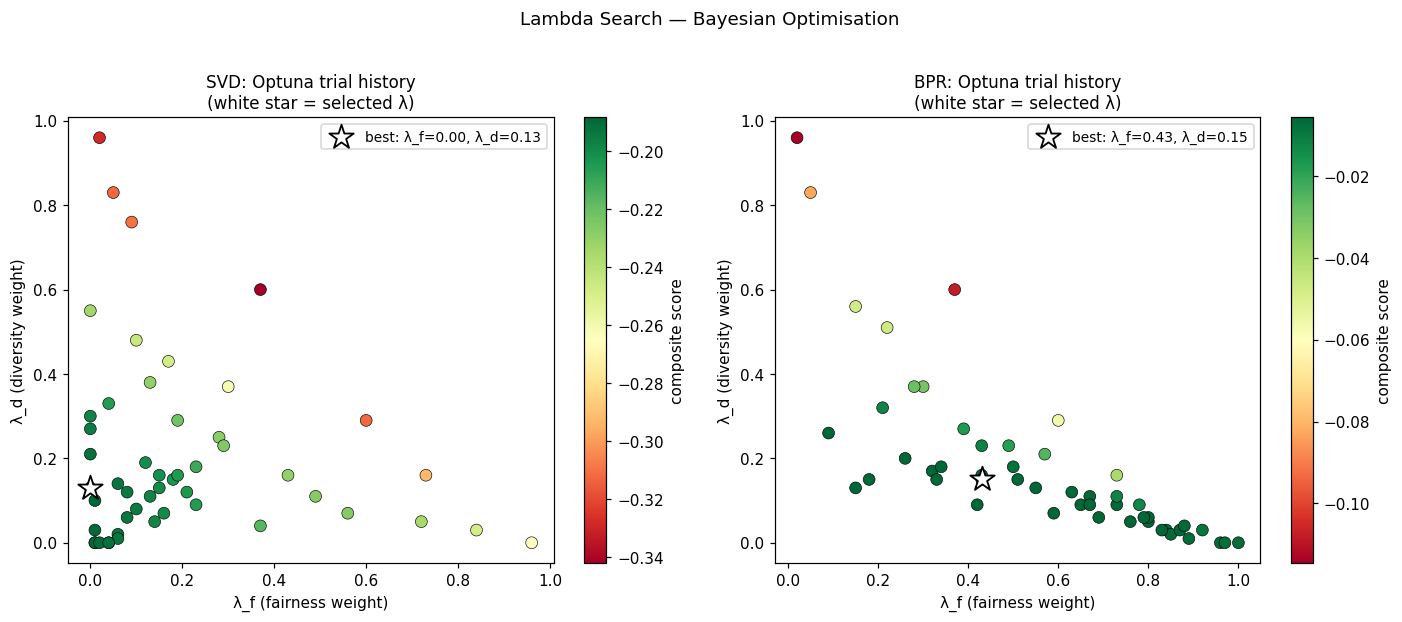

In [17]:
# Visualise Optuna trial history as scatter (lam_f vs lam_d, colour = composite)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, hist_df), best_lf, best_ld in zip(
        axes,
        [('SVD', optuna_svd), ('BPR', optuna_bpr)],
        [best_lf_svd, best_lf_bpr],
        [best_ld_svd, best_ld_bpr]):
    sc = ax.scatter(hist_df['lam_f'], hist_df['lam_d'],
                    c=hist_df['composite'], cmap='RdYlGn', s=60, edgecolor='k', linewidth=0.4)
    ax.scatter([best_lf], [best_ld], marker='*', s=280, color='white',
               edgecolor='black', linewidth=1.2, zorder=5,
               label=f'best: λ_f={best_lf:.2f}, λ_d={best_ld:.2f}')
    ax.set_xlabel('λ_f (fairness weight)')
    ax.set_ylabel('λ_d (diversity weight)')
    ax.set_title(f'{name}: Optuna trial history\n(white star = selected λ)', fontsize=11)
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='composite score')

plt.suptitle('Lambda Search — Bayesian Optimisation', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('lambda_grid_search.png', dpi=110, bbox_inches='tight')
plt.show()


In [18]:
# Re-rank all users using best lambdas
print('Re-ranking all users (Top-K and JFDS with best lambdas) ...')
lists = {}
for model_name, pools in [('SVD', svd_pools), ('BPR', bpr_pools)]:
    lf = best_lambdas[model_name]['lam_f']
    ld = best_lambdas[model_name]['lam_d']
    topk_lists, jfds_lists = {}, {}
    for u in range(N_USERS):
        cand_ids, cand_rel = pools[u]
        if len(cand_ids) == 0:
            continue
        topk_lists[u] = topk_rerank(cand_ids, cand_rel)
        jfds_lists[u] = jfds_rerank(cand_ids, cand_rel, lam_f=lf, lam_d=ld)
    lists[(model_name, 'TopK')] = topk_lists
    lists[(model_name, 'JFDS')] = jfds_lists
    print(f"  {model_name}: λ_f={lf:.2f} λ_d={ld:.2f} — "
          f"{len(topk_lists)} Top-K lists, {len(jfds_lists)} JFDS lists")


Re-ranking all users (Top-K and JFDS with best lambdas) ...
  SVD: λ_f=0.00 λ_d=0.13 — 6040 Top-K lists, 6040 JFDS lists
  BPR: λ_f=0.43 λ_d=0.15 — 6040 Top-K lists, 6040 JFDS lists


---
## 5. Evaluation Metrics  🔒 FIXED

Includes ILD (intra-list diversity), novelty-based fairness, Shannon entropy, Gini, calibration KL, and aggregate diversity helpers needed for R9/R10.

In [19]:
def precision_recall_ndcg(rec_list, relevant_set, grades, k=K):
    rec  = rec_list[:k]
    hits = len(set(rec) & relevant_set)
    prec = hits / k
    recl = hits / max(1, len(relevant_set))
    dcg  = sum(grades.get(item, 0) / np.log2(r + 2) for r, item in enumerate(rec))
    idcg = sum(g / np.log2(r + 2) for r, g in enumerate(sorted(grades.values(), reverse=True)[:k]))
    return prec, recl, (dcg / idcg if idcg > 0 else 0.0)

def ild(rec_list):
    """⚡ Vectorised ILD using GENRE_SIM submatrix."""
    if len(rec_list) < 2:
        return 0.0
    idx  = np.array(rec_list)
    sub  = GENRE_SIM[np.ix_(idx, idx)]
    n    = len(idx)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    return float(1.0 - sub[mask].mean())

def shannon_entropy(rec_list):
    dist = genre_vec[rec_list].mean(axis=0)
    dist = dist / dist.sum()
    return float(-np.sum([p * np.log2(p) for p in dist if p > 0]))

def gini(values):
    v = np.sort(np.asarray(values, dtype=float))
    n = len(v)
    if v.sum() == 0:
        return 0.0
    cum = np.cumsum(v)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)

def calibration_kl(rec_list, user_train_items, alpha=0.01):
    if len(user_train_items) == 0:
        return 0.0
    p = genre_vec[list(user_train_items)].mean(axis=0)
    p = p / p.sum()
    q = genre_vec[rec_list].mean(axis=0)
    q = (1 - alpha) * q + alpha * p
    q = q / q.sum()
    return float(np.sum(p * np.log((p + 1e-12) / (q + 1e-12))))

def novelty_fairness(rec_list):
    return float(np.mean([1 - pop_norm[i] for i in rec_list]))

# ── Aggregate diversity helpers (for R10) ─────────────────────────────────────
def aggregate_diversity(rec_lists_dict):
    """Number of unique items recommended across all users."""
    all_items = set()
    for rec in rec_lists_dict.values():
        all_items.update(rec)
    return len(all_items)

def exposure_vector(rec_lists_dict, n_items=N_ITEMS):
    """Item exposure count vector across all users."""
    exp = np.zeros(n_items)
    for rec in rec_lists_dict.values():
        for i in rec:
            exp[i] += 1
    return exp


In [20]:
# Per-user metrics for every (base_model, method) combination
rows = []
for (model_name, method), rec_lists in lists.items():
    for u, rec in rec_lists.items():
        relevant_set = test_relevant.get(u, set())
        grades       = test_grades.get(u, {})
        p, r, n_ndcg = precision_recall_ndcg(rec, relevant_set, grades)
        rows.append({
            'user': u, 'base_model': model_name, 'method': method,
            'precision': p, 'recall': r, 'ndcg': n_ndcg,
            'D': ild(rec), 'F': novelty_fairness(rec),
            'H': shannon_entropy(rec), 'gini_exp': gini(pop_count[rec]),
            'calibration_kl': calibration_kl(rec, train_seen.get(u, set())),
        })

metrics_long = pd.DataFrame(rows)
metrics_long['U'] = metrics_long['ndcg']
print(f"metrics_long: {len(metrics_long):,} rows")
metrics_long.head()


metrics_long: 24,160 rows


,user,base_model,method,precision,recall,ndcg,D,F,H,gini_exp,calibration_kl,U
0,0,SVD,TopK,0.0,0.0,0.050723,0.671337,0.718841,2.249465,0.505737,1.094961,0.050723
1,1,SVD,TopK,0.0,0.0,0.052529,0.844295,0.621456,3.082663,0.384245,0.904888,0.052529
2,2,SVD,TopK,0.0,0.0,0.000000,0.793662,0.654379,2.634893,0.465943,2.270991,0.000000
3,3,SVD,TopK,0.0,0.0,0.000000,0.723907,0.745778,2.645732,0.384224,1.658128,0.000000
4,4,SVD,TopK,0.0,0.0,0.000000,0.610052,0.821456,2.248991,0.362855,1.451694,0.000000


In [21]:
# Headline comparison table
summary = (metrics_long
           .groupby(['base_model', 'method'])
           [['precision', 'recall', 'ndcg', 'D', 'F', 'H', 'gini_exp', 'calibration_kl']]
           .mean().round(4))

sys_rows = []
for (model_name, method), rec_lists in lists.items():
    exposure   = exposure_vector(rec_lists)
    coverage   = (exposure > 0).sum() / N_ITEMS
    exp_gini   = gini(exposure)
    agg_div    = aggregate_diversity(rec_lists)
    tier_share = (pd.Series(tier[np.repeat(np.arange(N_ITEMS), exposure.astype(int))])
                  .value_counts(normalize=True).reindex(TIERS).fillna(0))
    sys_rows.append({'base_model': model_name, 'method': method,
                     'agg_diversity': agg_div, 'coverage': coverage,
                     'exposure_gini': exp_gini,
                     'head_share': tier_share['head'],
                     'mid_share':  tier_share['mid'],
                     'tail_share': tier_share['tail']})

system_summary = pd.DataFrame(sys_rows).set_index(['base_model', 'method']).round(4)
display(summary)
display(system_summary)


precision  recall    ndcg       D       F       H  \
base_model method                                                      
BPR        JFDS       0.0806  0.0492  0.0967  0.6958  0.2950  3.0449   
           TopK       0.0800  0.0483  0.0952  0.6680  0.2915  2.9982   
SVD        JFDS       0.0454  0.0262  0.0505  0.7609  0.7052  2.7379   
           TopK       0.0456  0.0257  0.0505  0.7288  0.7047  2.6308   

                   gini_exp  calibration_kl  
base_model method                            
BPR        JFDS      0.0771          1.0410  
           TopK      0.0760          1.1226  
SVD        JFDS      0.4012          1.3297  
           TopK      0.4035          1.3905

agg_diversity  coverage  exposure_gini  head_share  \
base_model method                                                       
SVD        TopK              585    0.1507         0.9799      0.7317   
           JFDS              585    0.1507         0.9800      0.7391   
BPR        TopK              119    0.0306         0.9945      1.0000   
           JFDS              122    0.0314         0.9944      1.0000   

                   mid_share  tail_share  
base_model method                         
SVD        TopK       0.1026      0.1657  
           JFDS       0.0996      0.1613  
BPR        TopK       0.0000      0.0000  
           JFDS       0.0000      0.0000

---
## R1 — Pareto Frontier (SVD vs. BPR)

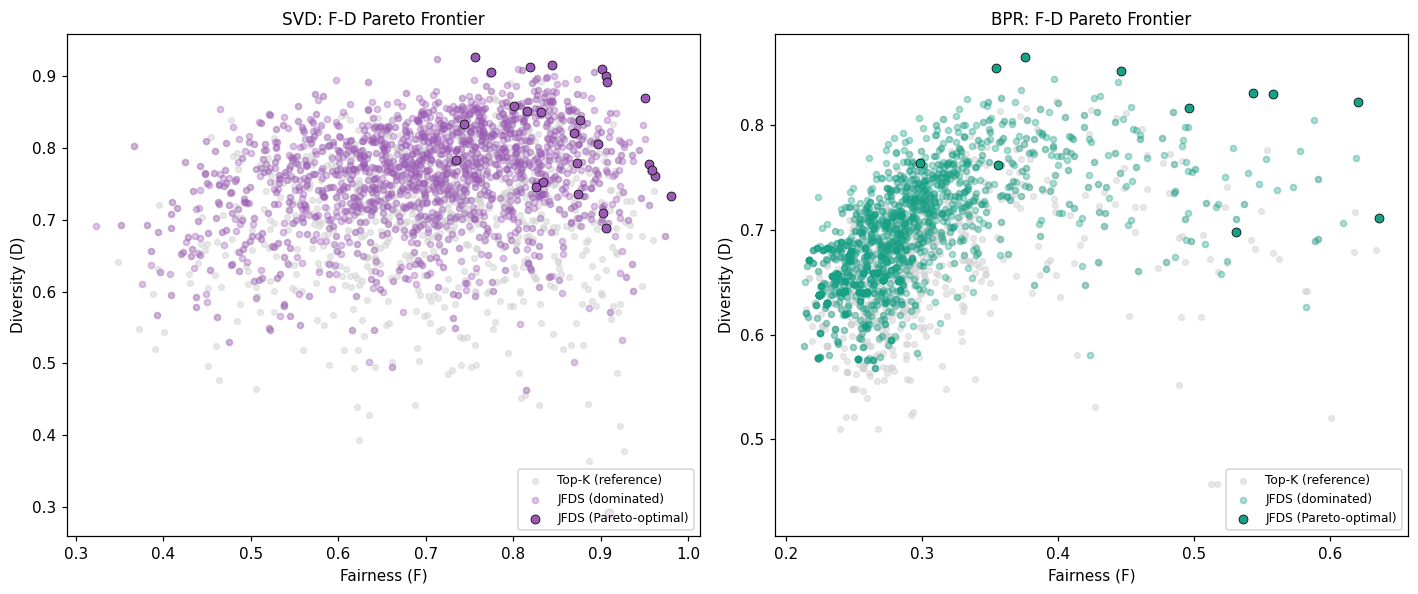

,n_pareto_optimal_jfds,n_jfds_sampled,pareto_pearson_r,pct_topk_dominated_by_jfds
SVD,27.0,1500.0,-0.300,99.133
BPR,11.0,1500.0,-0.232,99.667


In [22]:
def pareto_mask(vals):
    n = len(vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        if dominated[i]:
            continue
        diff = vals - vals[i]
        better_eq = np.all(diff >= -1e-12, axis=1)
        strictly  = np.any(diff >  1e-9,  axis=1)
        dom = better_eq & strictly
        dom[i] = False
        if dom.any():
            dominated[i] = True
    return ~dominated

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
pareto_stats = {}

for ax, model_name, color in zip(axes, ['SVD', 'BPR'], [C_SVD, C_BPR]):
    jfds_pts = metrics_long[(metrics_long.base_model == model_name) & (metrics_long.method == 'JFDS')]
    topk_pts = metrics_long[(metrics_long.base_model == model_name) & (metrics_long.method == 'TopK')]
    jfds_s = jfds_pts.sample(min(ANALYSIS_SAMPLE_N, len(jfds_pts)), random_state=RANDOM_SEED)
    topk_s = topk_pts.sample(min(ANALYSIS_SAMPLE_N, len(topk_pts)), random_state=RANDOM_SEED)

    vals = jfds_s[['F', 'D', 'U']].values
    mask = pareto_mask(vals)

    ax.scatter(topk_s['F'], topk_s['D'], s=14, c='lightgrey', alpha=0.5, label='Top-K (reference)')
    ax.scatter(jfds_s.loc[~mask, 'F'], jfds_s.loc[~mask, 'D'], s=16, c=color, alpha=0.35, label='JFDS (dominated)')
    ax.scatter(jfds_s.loc[ mask, 'F'], jfds_s.loc[ mask, 'D'], s=34, c=color,
               edgecolor='black', linewidth=0.5, label='JFDS (Pareto-optimal)')
    ax.set_xlabel('Fairness (F)'); ax.set_ylabel('Diversity (D)')
    ax.set_title(f'{model_name}: F-D Pareto Frontier', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')

    r_pareto = np.corrcoef(jfds_s.loc[mask, 'F'], jfds_s.loc[mask, 'D'])[0, 1] if mask.sum() > 2 else np.nan
    topk_vals = topk_s[['F', 'D', 'U']].values
    topk_dominated = sum(
        1 for i in range(len(topk_s))
        if (np.all(vals - topk_vals[i] >= -1e-12, axis=1) & np.any(vals - topk_vals[i] > 1e-9, axis=1)).any()
    )
    pareto_stats[model_name] = {
        'n_pareto_optimal_jfds': int(mask.sum()),
        'n_jfds_sampled': len(jfds_s),
        'pareto_pearson_r': r_pareto,
        'pct_topk_dominated_by_jfds': 100 * topk_dominated / len(topk_s),
    }

plt.tight_layout()
plt.savefig('r1_pareto_frontier.png', dpi=110, bbox_inches='tight')
plt.show()
pd.DataFrame(pareto_stats).T.round(3)


---
## R2 — Scaling Law (AIC/BIC)

,Model,Equation,AIC,BIC
0,Saturation,"Saturation fit (a=0.8316, b=0.0583)",-16769.274642,-16757.261907
1,Quadratic,D = 0.5496 + 0.6028*F + -0.4065*F^2,-16741.908109,-16723.889007
2,Log,"Log fit (a=0.7972, b=0.0855)",-16705.508485,-16693.495750
3,Power,"Power fit (a=0.7987, b=0.1163)",-16693.484656,-16681.471921
4,Linear,D = 0.6431 + 0.1710*F,-16589.559492,-16577.546757


Best model by AIC: Saturation  ->  Saturation fit (a=0.8316, b=0.0583)


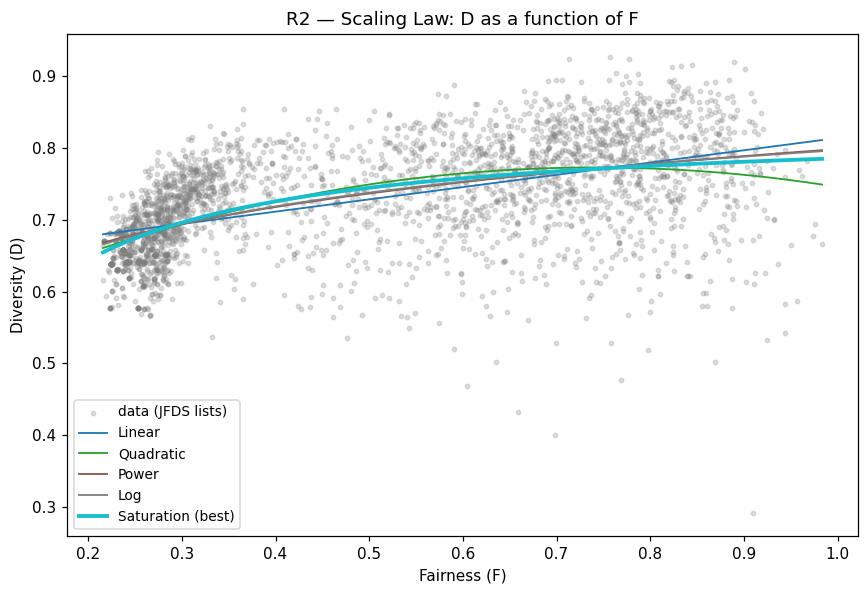

In [23]:
jfds_all = metrics_long[metrics_long.method == 'JFDS']
pool = jfds_all.sample(min(ANALYSIS_SAMPLE_N * 2, len(jfds_all)), random_state=RANDOM_SEED)
F_vals = pool['F'].values
D_vals = pool['D'].values
eps = 1e-6

def aic_bic(y, y_pred, k_params):
    n   = len(y)
    rss = max(np.sum((y - y_pred) ** 2), 1e-12)
    return n * np.log(rss/n) + 2 * k_params, n * np.log(rss/n) + k_params * np.log(n)

models_fit = {}
c1 = np.polyfit(F_vals, D_vals, 1)
models_fit['Linear'] = {'params': c1, 'pred': np.polyval(c1, F_vals), 'k': 2,
                        'eq': f"D = {c1[1]:.4f} + {c1[0]:.4f}*F"}
c2 = np.polyfit(F_vals, D_vals, 2)
models_fit['Quadratic'] = {'params': c2, 'pred': np.polyval(c2, F_vals), 'k': 3,
                           'eq': f"D = {c2[2]:.4f} + {c2[1]:.4f}*F + {c2[0]:.4f}*F^2"}

for name, fn, p0 in [
    ('Power',      lambda x, a, b: a * np.power(x + eps, b),          [1, 0.5]),
    ('Log',        lambda x, a, b: a + b * np.log(x + eps),            [0, 0.1]),
    ('Saturation', lambda x, a, b: a * x / (b + x + eps),              [1, 0.1]),
]:
    try:
        popt, _ = curve_fit(fn, F_vals, D_vals, p0=p0, maxfev=10000)
        models_fit[name] = {'params': popt, 'pred': fn(F_vals, *popt), 'k': 2,
                            'eq': f"{name} fit (a={popt[0]:.4f}, b={popt[1]:.4f})"}
    except RuntimeError:
        pass

rows_r2 = []
for name, m in models_fit.items():
    aic, bic = aic_bic(D_vals, m['pred'], m['k'])
    rows_r2.append({'Model': name, 'Equation': m['eq'], 'AIC': aic, 'BIC': bic})
scaling_table = pd.DataFrame(rows_r2).sort_values('AIC').reset_index(drop=True)
display(scaling_table)

best_name = scaling_table.iloc[0]['Model']
print(f"Best model by AIC: {best_name}  ->  {scaling_table.iloc[0]['Equation']}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(F_vals, D_vals, s=8, alpha=0.25, color='grey', label='data (JFDS lists)')
F_grid = np.linspace(F_vals.min(), F_vals.max(), 200)
for (name, m), col in zip(models_fit.items(), plt.cm.tab10(np.linspace(0, 1, len(models_fit)))):
    try:
        if name in ('Linear', 'Quadratic'):
            yg = np.polyval(m['params'], F_grid)
        else:
            from scipy.optimize import curve_fit as _cf
            fn_map = {
                'Power':      lambda x, a, b: a * np.power(x + eps, b),
                'Log':        lambda x, a, b: a + b * np.log(x + eps),
                'Saturation': lambda x, a, b: a * x / (b + x + eps),
            }
            yg = fn_map[name](F_grid, *m['params'])
        lw = 2.5 if name == best_name else 1.2
        ax.plot(F_grid, yg, color=col, linewidth=lw,
                label=f"{name}{' (best)' if name == best_name else ''}")
    except Exception:
        pass
ax.set_xlabel('Fairness (F)'); ax.set_ylabel('Diversity (D)')
ax.set_title('R2 — Scaling Law: D as a function of F', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('r2_scaling_law.png', dpi=110, bbox_inches='tight')
plt.show()


---
## R3 — Regime Analysis

,quintile,F_range,n,slope,slope_se
0,Q1,"[0.216, 0.270]",600,0.4546,0.1037
1,Q2,"[0.270, 0.330]",601,1.4518,0.0930
2,Q3,"[0.330, 0.598]",599,0.0271,0.0301
3,Q4,"[0.598, 0.746]",600,0.2673,0.0654
4,Q5,"[0.746, 0.983]",600,-0.2087,0.0612


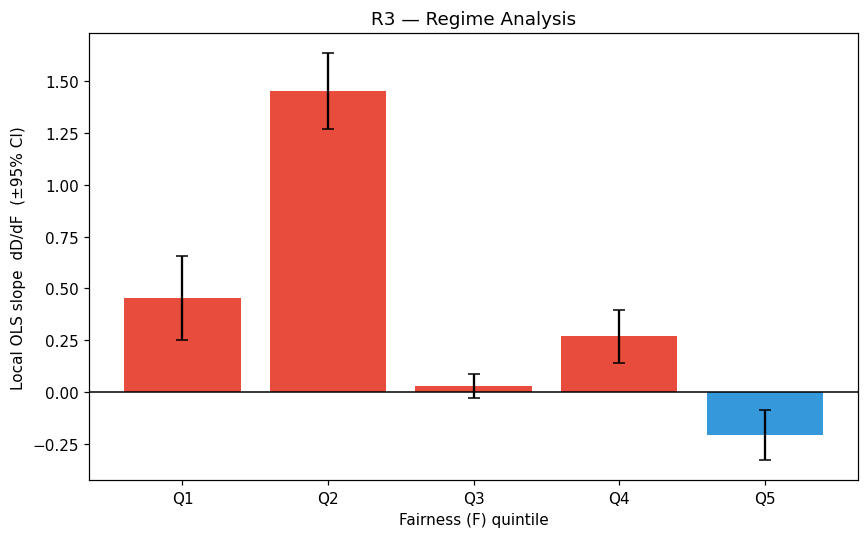

Positive-slope regimes: 4/5   Negative: 1/5


In [24]:
pool = pool.copy()
pool['F_quintile'] = pd.qcut(pool['F'], 5, labels=[f'Q{i+1}' for i in range(5)], duplicates='drop')

slope_rows = []
for q, g in pool.groupby('F_quintile', observed=True):
    if len(g) < 3 or g['F'].std() < 1e-9:
        continue
    c, cov = np.polyfit(g['F'], g['D'], 1, cov=True)
    slope_rows.append({'quintile': q, 'F_range': f"[{g['F'].min():.3f}, {g['F'].max():.3f}]",
                       'n': len(g), 'slope': c[0], 'slope_se': np.sqrt(cov[0, 0])})

regime_df = pd.DataFrame(slope_rows)
display(regime_df.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(regime_df['quintile'].astype(str), regime_df['slope'],
       yerr=regime_df['slope_se'] * 1.96,
       color=[C_JFDS if s > 0 else C_TOPK for s in regime_df['slope']], capsize=4)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Fairness (F) quintile')
ax.set_ylabel('Local OLS slope  dD/dF  (±95% CI)')
ax.set_title('R3 — Regime Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('r3_regime_analysis.png', dpi=110, bbox_inches='tight')
plt.show()

n_pos = int((regime_df['slope'] > 0).sum())
n_neg = int((regime_df['slope'] < 0).sum())
print(f"Positive-slope regimes: {n_pos}/{len(regime_df)}   Negative: {n_neg}/{len(regime_df)}")


---
## R4 — Conservation Invariant

Best invariant: F^-0.0 * D^-0.0   (CV = 0.0000)
Bootstrap 95% CI:  alpha [-0.00, 0.00]   beta [-0.00, 0.00]


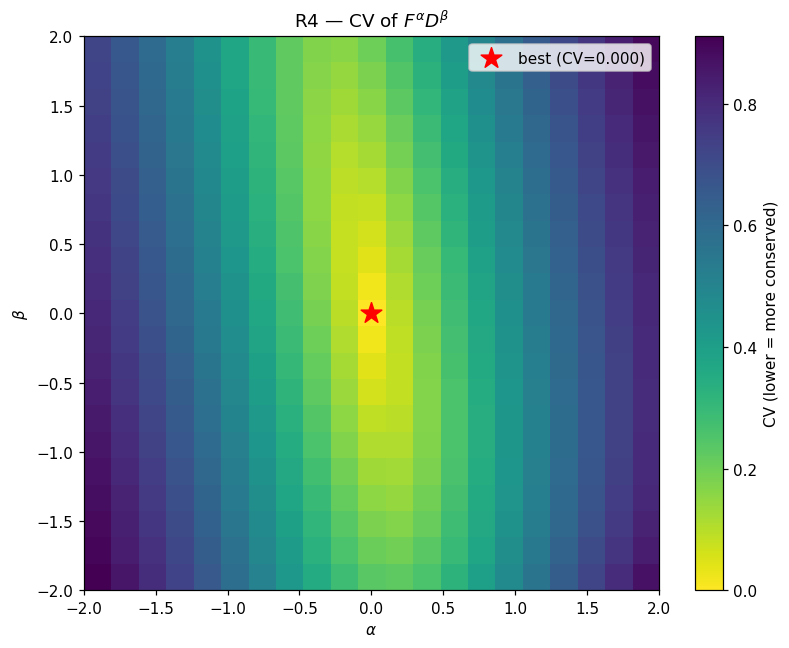

In [25]:
F_arr = pool['F'].values + 1e-6
D_arr = pool['D'].values + 1e-6
alphas = np.round(np.arange(-2, 2.01, 0.2), 2)
betas  = np.round(np.arange(-2, 2.01, 0.2), 2)

def cv_grid(F_arr, D_arr, alphas, betas):
    grid = np.zeros((len(alphas), len(betas)))
    for ai, a in enumerate(alphas):
        Fp = F_arr ** a
        for bi, b in enumerate(betas):
            Q  = Fp * (D_arr ** b)
            m  = np.mean(Q)
            grid[ai, bi] = np.std(Q) / abs(m) if abs(m) > 1e-9 else np.inf
    return grid

grid = cv_grid(F_arr, D_arr, alphas, betas)
best_idx = np.unravel_index(np.argmin(grid), grid.shape)
best_alpha, best_beta = alphas[best_idx[0]], betas[best_idx[1]]
best_cv = grid[best_idx]
print(f"Best invariant: F^{best_alpha} * D^{best_beta}   (CV = {best_cv:.4f})")

B, n = 200, len(F_arr)
boot_alpha, boot_beta = [], []
for _ in range(B):
    idx = RNG.integers(0, n, size=n)
    g   = cv_grid(F_arr[idx], D_arr[idx], alphas, betas)
    bi  = np.unravel_index(np.argmin(g), g.shape)
    boot_alpha.append(alphas[bi[0]]); boot_beta.append(betas[bi[1]])

alpha_ci = np.percentile(boot_alpha, [2.5, 97.5])
beta_ci  = np.percentile(boot_beta,  [2.5, 97.5])
print(f"Bootstrap 95% CI:  alpha [{alpha_ci[0]:.2f}, {alpha_ci[1]:.2f}]   "
      f"beta [{beta_ci[0]:.2f}, {beta_ci[1]:.2f}]")

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(grid.T, origin='lower',
               extent=[alphas.min(), alphas.max(), betas.min(), betas.max()],
               aspect='auto', cmap='viridis_r')
ax.scatter([best_alpha], [best_beta], color='red', marker='*', s=200,
           label=f'best (CV={best_cv:.3f})')
ax.set_xlabel(r'$\alpha$'); ax.set_ylabel(r'$\beta$')
ax.set_title(r'R4 — CV of $F^\alpha D^\beta$', fontsize=12)
plt.colorbar(im, ax=ax, label='CV (lower = more conserved)')
ax.legend()
plt.tight_layout()
plt.savefig('r4_conservation_invariant.png', dpi=110, bbox_inches='tight')
plt.show()


---
## R5 — Coupling Coefficient ρ_FD

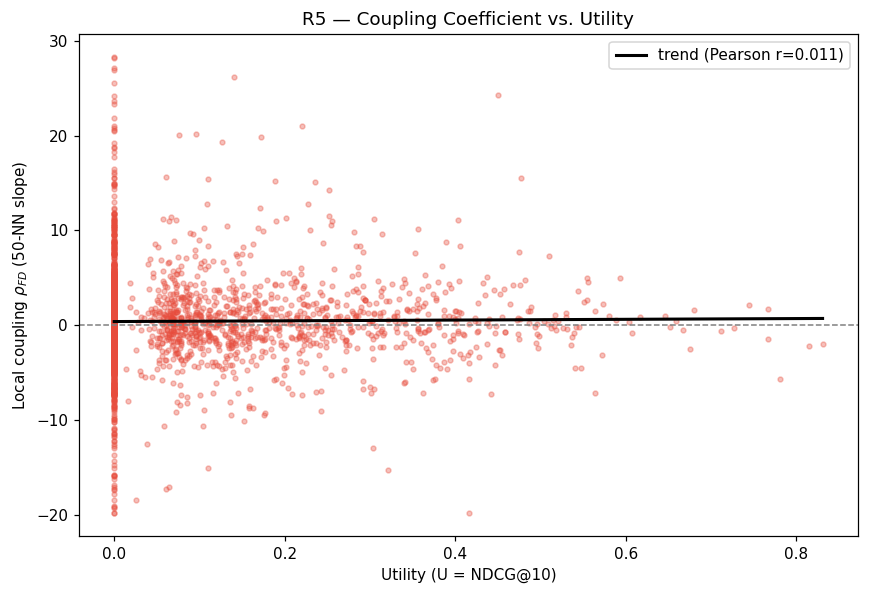

Pearson r(rho_FD, Utility) = 0.0112


In [26]:
order    = np.argsort(pool['F'].values)
F_sorted = pool['F'].values[order]
D_sorted = pool['D'].values[order]
U_sorted = pool['U'].values[order]
n, half  = len(F_sorted), 25

rho_fd = np.full(n, np.nan)
for pos in range(n):
    lo, hi = max(0, pos - half), min(n, pos + half + 1)
    Fw, Dw = F_sorted[lo:hi], D_sorted[lo:hi]
    if len(Fw) > 5 and np.var(Fw) > 1e-9:
        rho_fd[pos] = np.cov(Fw, Dw)[0, 1] / np.var(Fw)

valid = ~np.isnan(rho_fd)
r_coupling = np.corrcoef(rho_fd[valid], U_sorted[valid])[0, 1]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(U_sorted[valid], rho_fd[valid], s=10, alpha=0.35, color=C_JFDS)
c  = np.polyfit(U_sorted[valid], rho_fd[valid], 1)
xg = np.linspace(U_sorted[valid].min(), U_sorted[valid].max(), 100)
ax.plot(xg, np.polyval(c, xg), color='black', lw=2,
        label=f'trend (Pearson r={r_coupling:.3f})')
ax.axhline(0, color='grey', ls='--', lw=1)
ax.set_xlabel('Utility (U = NDCG@10)')
ax.set_ylabel(r'Local coupling $\rho_{{FD}}$ (50-NN slope)')
ax.set_title('R5 — Coupling Coefficient vs. Utility', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('r5_coupling_coefficient.png', dpi=110, bbox_inches='tight')
plt.show()
print(f"Pearson r(rho_FD, Utility) = {r_coupling:.4f}")


---
## R6 — Information Theory

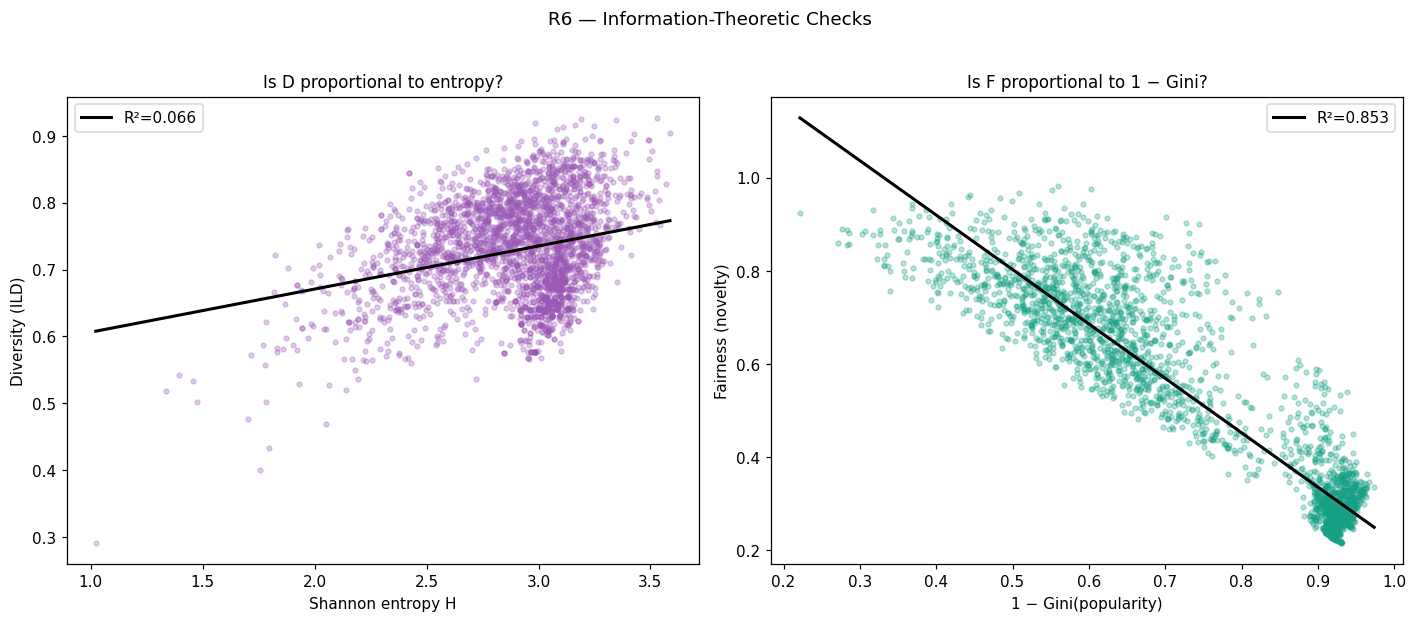

D ~ H:          R² = 0.0662
F ~ 1-Gini:     R² = 0.8529


In [27]:
H_vals        = pool['H'].values
one_minus_gini = 1 - pool['gini_exp'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

c1    = np.polyfit(H_vals, pool['D'].values, 1)
pred1 = np.polyval(c1, H_vals)
r2_1  = 1 - np.sum((pool['D'].values - pred1)**2) / np.sum((pool['D'].values - pool['D'].values.mean())**2)
axes[0].scatter(H_vals, pool['D'], s=10, alpha=0.3, color=C_SVD)
xg = np.linspace(H_vals.min(), H_vals.max(), 100)
axes[0].plot(xg, np.polyval(c1, xg), color='black', lw=2, label=f'R²={r2_1:.3f}')
axes[0].set_xlabel('Shannon entropy H'); axes[0].set_ylabel('Diversity (ILD)')
axes[0].set_title('Is D proportional to entropy?', fontsize=11)
axes[0].legend()

c2    = np.polyfit(one_minus_gini, pool['F'].values, 1)
pred2 = np.polyval(c2, one_minus_gini)
r2_2  = 1 - np.sum((pool['F'].values - pred2)**2) / np.sum((pool['F'].values - pool['F'].values.mean())**2)
axes[1].scatter(one_minus_gini, pool['F'], s=10, alpha=0.3, color=C_BPR)
xg2 = np.linspace(one_minus_gini.min(), one_minus_gini.max(), 100)
axes[1].plot(xg2, np.polyval(c2, xg2), color='black', lw=2, label=f'R²={r2_2:.3f}')
axes[1].set_xlabel('1 − Gini(popularity)'); axes[1].set_ylabel('Fairness (novelty)')
axes[1].set_title('Is F proportional to 1 − Gini?', fontsize=11)
axes[1].legend()

plt.suptitle('R6 — Information-Theoretic Checks', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('r6_information_theory.png', dpi=110, bbox_inches='tight')
plt.show()
print(f"D ~ H:          R² = {r2_1:.4f}")
print(f"F ~ 1-Gini:     R² = {r2_2:.4f}")


---
## R7 — Paired Significance Tests

In [28]:
sig_rows = []
for model_name in ['SVD', 'BPR']:
    topk_df = metrics_long[(metrics_long.base_model == model_name) & (metrics_long.method == 'TopK')].set_index('user')
    jfds_df = metrics_long[(metrics_long.base_model == model_name) & (metrics_long.method == 'JFDS')].set_index('user')
    common  = topk_df.index.intersection(jfds_df.index)
    topk_df, jfds_df = topk_df.loc[common], jfds_df.loc[common]

    for metric in ['precision', 'recall', 'ndcg', 'D', 'F', 'calibration_kl']:
        a, b = topk_df[metric].values, jfds_df[metric].values
        diff = b - a
        try:
            w_stat, w_p = stats.wilcoxon(a, b)
        except ValueError:
            w_stat, w_p = np.nan, np.nan
        t_stat, t_p = stats.ttest_rel(b, a)
        sig_rows.append({
            'base_model': model_name, 'metric': metric,
            'mean_TopK': a.mean(), 'mean_JFDS': b.mean(),
            'mean_delta': diff.mean(), 'wilcoxon_p': w_p, 'ttest_p': t_p,
            'JFDS_wins': int(np.sum(diff > 1e-9)),
            'JFDS_losses': int(np.sum(diff < -1e-9)),
            'ties': len(diff) - int(np.sum(diff > 1e-9)) - int(np.sum(diff < -1e-9)),
            'n_users': len(common),
        })

sig_table = pd.DataFrame(sig_rows).round(5)
sig_table


,base_model,metric,mean_TopK,mean_JFDS,mean_delta,wilcoxon_p,ttest_p,JFDS_wins,JFDS_losses,ties,n_users
0,SVD,precision,0.04560,0.04545,-0.00015,0.88285,0.54495,103,112,5825,6040
1,SVD,recall,0.02571,0.02615,0.00044,0.76372,0.05489,103,112,5825,6040
2,SVD,ndcg,0.05051,0.05050,-0.00000,0.87306,0.97765,459,449,5132,6040
3,SVD,D,0.72883,0.76093,0.03210,0.00000,0.00000,2861,188,2991,6040
4,SVD,F,0.70473,0.70518,0.00045,0.89602,0.08319,1290,1390,3360,6040
5,SVD,calibration_kl,1.39047,1.32974,-0.06073,0.00000,0.00000,878,1801,3361,6040
6,BPR,precision,0.07997,0.08061,0.00065,0.03207,0.07597,242,209,5589,6040
7,BPR,recall,0.04834,0.04919,0.00085,0.05238,0.01731,242,209,5589,6040
8,BPR,ndcg,0.09516,0.09673,0.00157,0.00000,0.00000,1207,1038,3795,6040
9,BPR,D,0.66796,0.69577,0.02781,0.00000,0.00000,3873,184,1983,6040


---
## R8 — Bootstrap Confidence Intervals

,base_model,metric,mean_delta,ci_low,ci_high
0,SVD,precision,-0.00015,-0.00061,0.00033
1,SVD,recall,0.00044,0.00002,0.00087
2,SVD,ndcg,-0.00000,-0.00034,0.00035
3,SVD,D,0.03210,0.03096,0.03326
4,SVD,F,0.00045,-0.00006,0.00094
5,SVD,calibration_kl,-0.06073,-0.06610,-0.05550
6,BPR,precision,0.00065,-0.00007,0.00136
7,BPR,recall,0.00085,0.00017,0.00157
8,BPR,ndcg,0.00157,0.00099,0.00217
9,BPR,D,0.02781,0.02699,0.02860


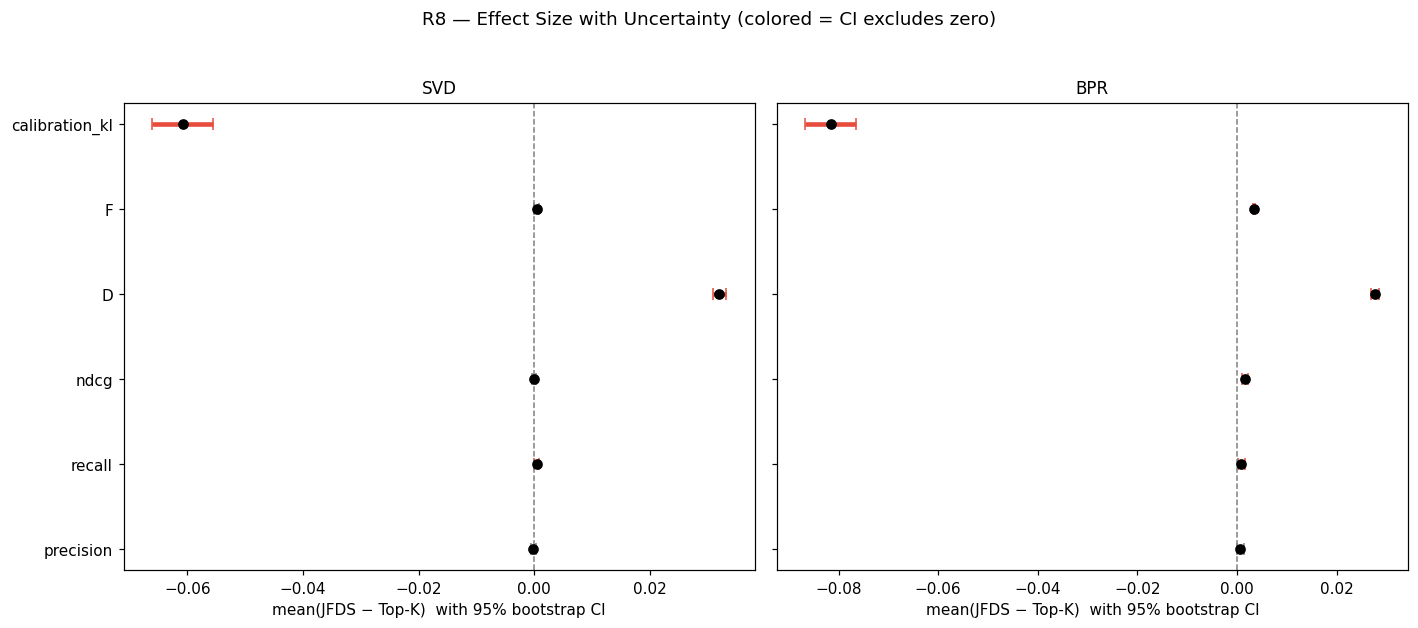

In [30]:
def bootstrap_delta_ci(a, b, n_boot=2000, seed=RANDOM_SEED):
    rng   = np.random.default_rng(seed)
    diffs = b - a
    boots = np.array([rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_boot)])
    return diffs.mean(), np.percentile(boots, [2.5, 97.5])

boot_rows = []
for model_name in ['SVD', 'BPR']:
    topk_df = metrics_long[(metrics_long.base_model == model_name) & (metrics_long.method == 'TopK')].set_index('user')
    jfds_df = metrics_long[(metrics_long.base_model == model_name) & (metrics_long.method == 'JFDS')].set_index('user')
    common  = topk_df.index.intersection(jfds_df.index)
    topk_df, jfds_df = topk_df.loc[common], jfds_df.loc[common]
    for metric in ['precision', 'recall', 'ndcg', 'D', 'F', 'calibration_kl']:
        mean_delta, ci = bootstrap_delta_ci(topk_df[metric].values, jfds_df[metric].values)
        boot_rows.append({'base_model': model_name, 'metric': metric,
                          'mean_delta': mean_delta, 'ci_low': ci[0], 'ci_high': ci[1]})

boot_df = pd.DataFrame(boot_rows)
display(boot_df.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, model_name in zip(axes, ['SVD', 'BPR']):
    sub = boot_df[boot_df.base_model == model_name].reset_index(drop=True)
    y   = np.arange(len(sub))
    colors_b = [C_JFDS if (lo > 0 or hi < 0) else 'grey' for lo, hi in zip(sub.ci_low, sub.ci_high)]

    # ecolor doesn't accept a per-point color array, so draw each errorbar individually
    for yi, md, lo, hi, col in zip(y, sub['mean_delta'], sub['ci_low'], sub['ci_high'], colors_b):
        ax.errorbar(md, yi,
                    xerr=[[md - lo], [hi - md]],
                    fmt='o', color='black', ecolor=col, elinewidth=3, capsize=4)

    ax.axvline(0, color='grey', ls='--', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(sub['metric'])
    ax.set_xlabel('mean(JFDS − Top-K)  with 95% bootstrap CI')
    ax.set_title(f'{model_name}', fontsize=11)

plt.suptitle('R8 — Effect Size with Uncertainty (colored = CI excludes zero)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig('r8_bootstrap_ci.png', dpi=110, bbox_inches='tight')
plt.show()

---
## R9 — Group Fairness by User Demographics  ✨ NEW

Break down NDCG, F (novelty), and D (ILD) by Gender, Age bucket, and Occupation.
Answers: *does JFDS improve recommendations equally across all user groups, or does it help some while hurting others?*


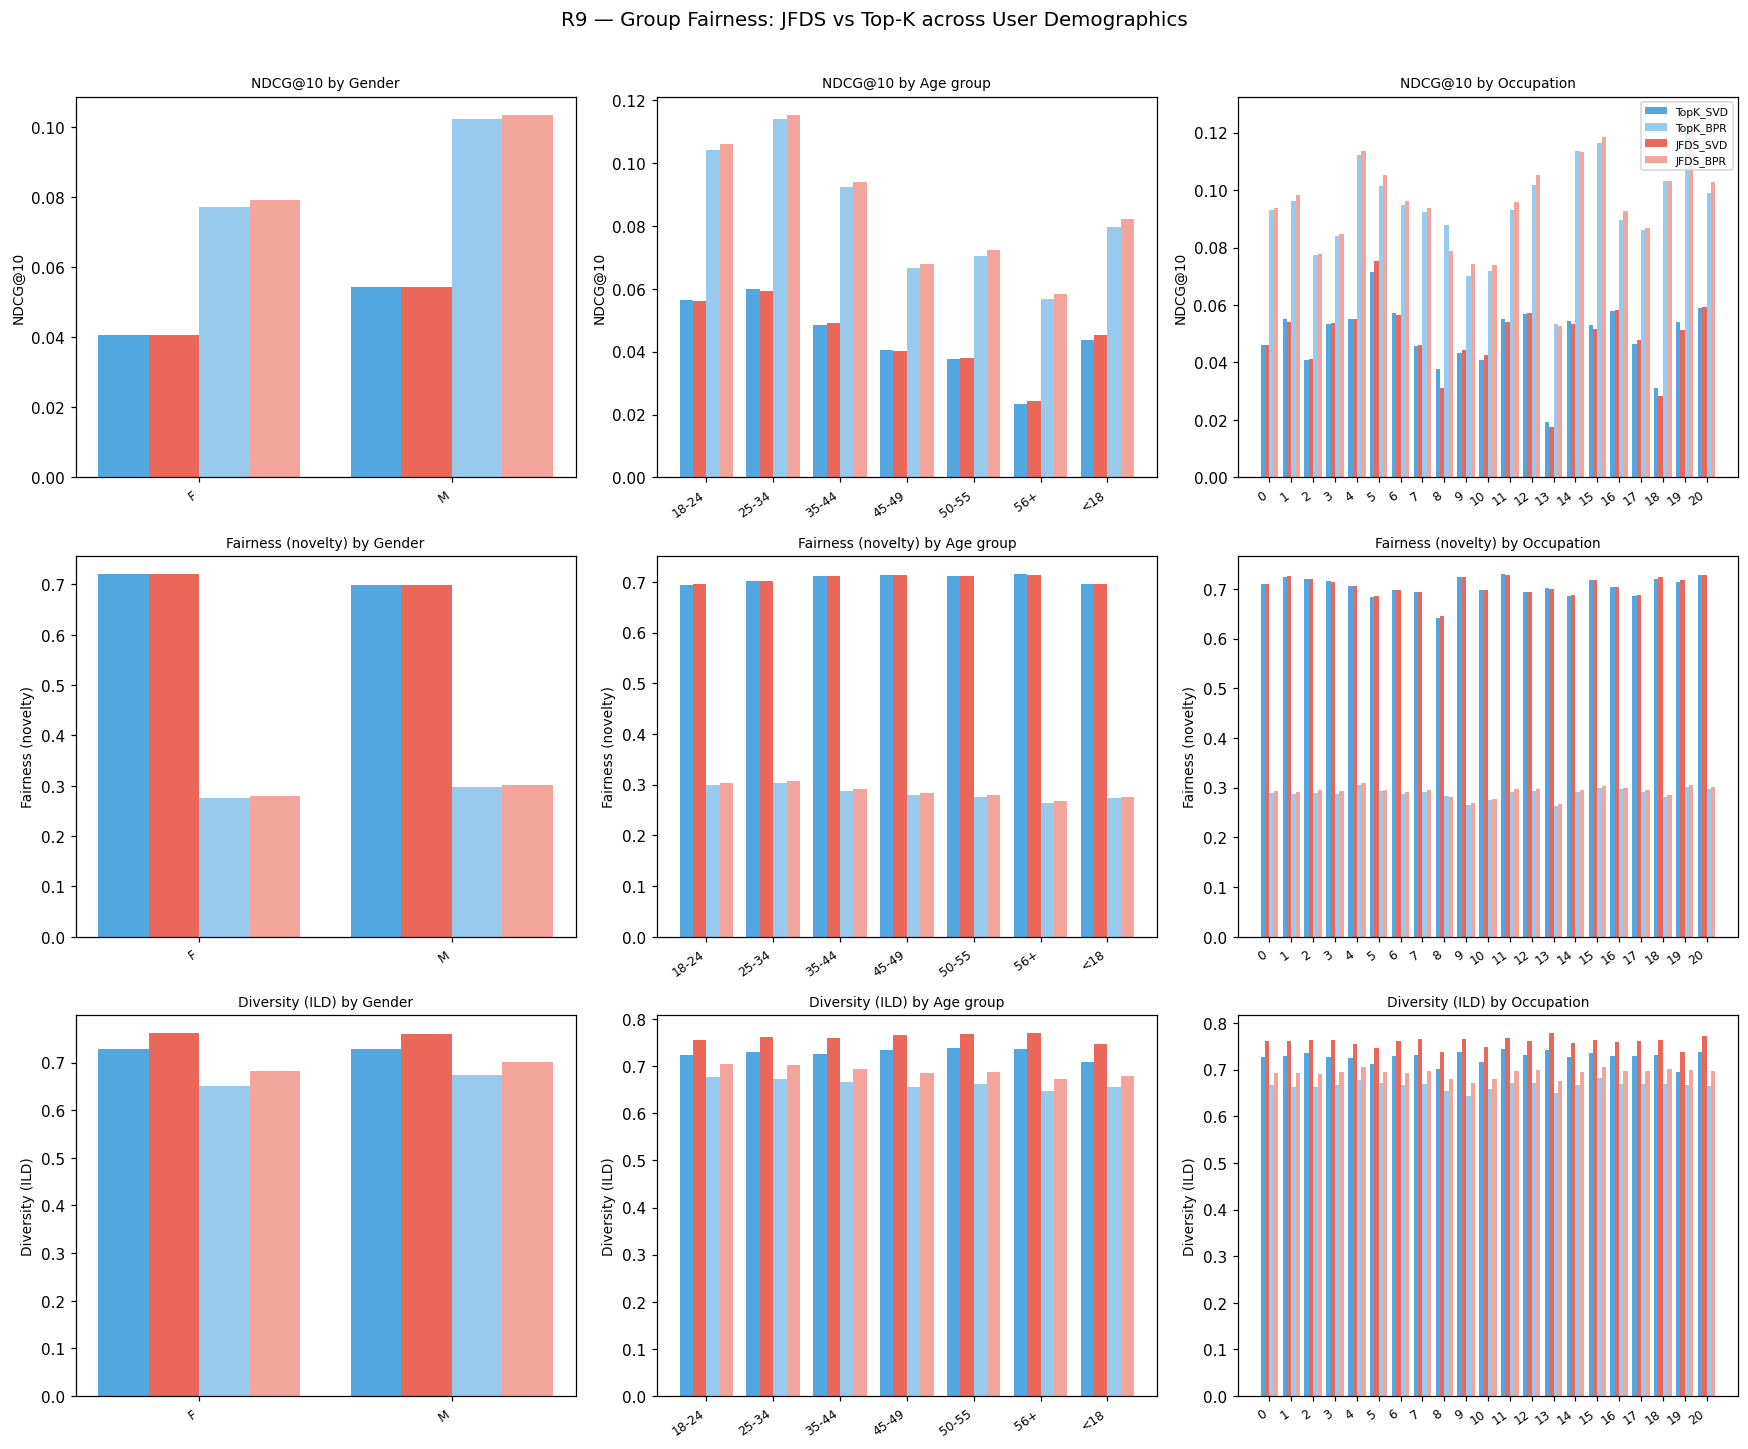


Kruskal-Wallis test: is the JFDS gain in NDCG uniform across groups?
  SVD × Gender: H=0.48  p=0.4879  (uniform gains)
  BPR × Gender: H=1.28  p=0.2581  (uniform gains)
  SVD × Age group: H=6.01  p=0.4222  (uniform gains)
  BPR × Age group: H=2.13  p=0.9073  (uniform gains)
  SVD × Occupation: H=22.04  p=0.3381  (uniform gains)
  BPR × Occupation: H=24.89  p=0.2057  (uniform gains)


In [31]:
# Merge user demographics into metrics_long
demo_cols = ['u_idx', 'Gender', 'Age', 'Occupation']
metrics_demo = metrics_long.merge(
    users_df[demo_cols].rename(columns={'u_idx': 'user'}),
    on='user', how='left'
)

# Age bucketing
age_map = {1: '<18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
metrics_demo['Age_label'] = metrics_demo['Age'].map(age_map).fillna('Unknown')

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
group_cols  = ['Gender', 'Age_label', 'Occupation']
group_titles = ['Gender', 'Age group', 'Occupation']
metric_pairs = [('ndcg', 'NDCG@10'), ('F', 'Fairness (novelty)'), ('D', 'Diversity (ILD)')]

for col_idx, (demo_col, demo_title) in enumerate(zip(group_cols, group_titles)):
    for row_idx, (metric, metric_label) in enumerate(metric_pairs):
        ax = axes[row_idx][col_idx]
        grp = (metrics_demo.groupby([demo_col, 'method', 'base_model'])[metric]
               .mean().reset_index())

        groups = sorted(grp[demo_col].unique())
        x      = np.arange(len(groups))
        width  = 0.2
        offsets = {'TopK_SVD': -1.5, 'JFDS_SVD': -0.5, 'TopK_BPR': 0.5, 'JFDS_BPR': 1.5}
        colors  = {'TopK_SVD': C_TOPK, 'JFDS_SVD': C_JFDS,
                   'TopK_BPR': '#85C1E9', 'JFDS_BPR': '#F1948A'}

        for method in ['TopK', 'JFDS']:
            for bm in ['SVD', 'BPR']:
                sub   = grp[(grp['method'] == method) & (grp['base_model'] == bm)]
                vals  = [sub[sub[demo_col] == g][metric].values[0]
                         if len(sub[sub[demo_col] == g]) > 0 else 0 for g in groups]
                key   = f'{method}_{bm}'
                ax.bar(x + offsets[key] * width, vals, width,
                       label=key, color=colors[key], alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=35, ha='right', fontsize=8)
        ax.set_ylabel(metric_label, fontsize=9)
        ax.set_title(f'{metric_label} by {demo_title}', fontsize=9)
        if row_idx == 0 and col_idx == 2:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle('R9 — Group Fairness: JFDS vs Top-K across User Demographics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('r9_group_fairness.png', dpi=110, bbox_inches='tight')
plt.show()

# Statistical test: does JFDS help all groups equally? (Kruskal-Wallis on delta per demo group)
print("\nKruskal-Wallis test: is the JFDS gain in NDCG uniform across groups?")
for demo_col, demo_title in zip(group_cols, group_titles):
    for bm in ['SVD', 'BPR']:
        topk_d = metrics_demo[(metrics_demo.method=='TopK') & (metrics_demo.base_model==bm)].set_index('user')
        jfds_d = metrics_demo[(metrics_demo.method=='JFDS') & (metrics_demo.base_model==bm)].set_index('user')
        common = topk_d.index.intersection(jfds_d.index)
        delta_df = pd.DataFrame({
            'delta_ndcg': jfds_d.loc[common, 'ndcg'].values - topk_d.loc[common, 'ndcg'].values,
            demo_col: jfds_d.loc[common, demo_col].values,
        })
        groups_data = [g['delta_ndcg'].values for _, g in delta_df.groupby(demo_col) if len(g) > 5]
        if len(groups_data) >= 2:
            h_stat, p_val = stats.kruskal(*groups_data)
            print(f"  {bm} × {demo_title}: H={h_stat:.2f}  p={p_val:.4f}"
                  f"  {'← unequal gains' if p_val < 0.05 else '(uniform gains)'}")


---
## R10 — Aggregate Diversity & Exposure Lorenz Curve  ✨ NEW

Answers:
1. How many *distinct* items does each strategy recommend across all users? (Aggregate diversity)
2. How equitably is exposure distributed across items? (Lorenz curve + Gini)
3. Is exposure significantly different between Top-K and JFDS for head/mid/tail items? (Chi-square)


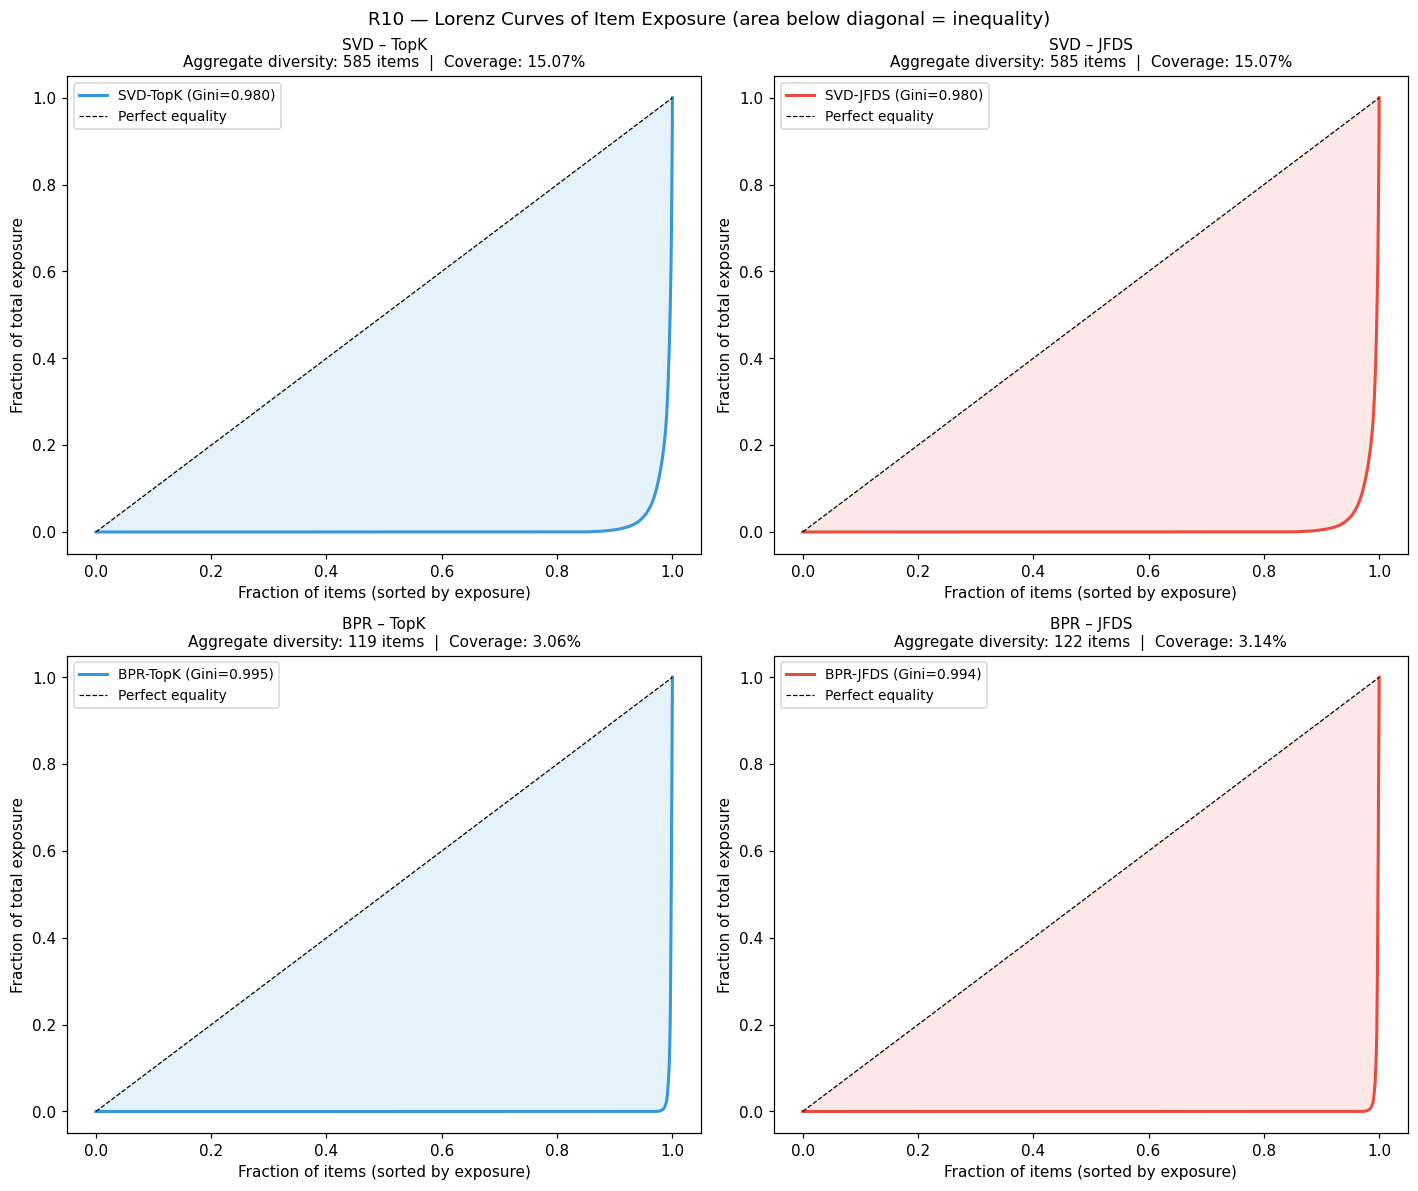

agg_diversity  coverage  exposure_gini  head_share  \
base_model method                                                       
SVD        TopK              585    0.1507         0.9799      0.7317   
           JFDS              585    0.1507         0.9800      0.7391   
BPR        TopK              119    0.0306         0.9945      1.0000   
           JFDS              122    0.0314         0.9944      1.0000   

                   mid_share  tail_share  
base_model method                         
SVD        TopK       0.1026      0.1657  
           JFDS       0.0996      0.1613  
BPR        TopK       0.0000      0.0000  
           JFDS       0.0000      0.0000


Chi-square test: JFDS vs Top-K tier exposure distribution
  SVD: chi2=8.67  p=1.31e-02  dof=2  ← significantly different
       TopK tier shares: {'head': np.float64(0.732), 'mid': np.float64(0.103), 'tail': np.float64(0.166)}
       JFDS tier shares: {'head': np.float64(0.739), 'mid': np.float64(0.1), 'tail': np.float64(0.161)}
  BPR: dropping tier(s) with zero total exposure from the test: ['mid', 'tail']
  BPR: not enough non-zero tiers remain (1) to run chi-square test — skipping.


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

agg_stats = []
for (model_name, method), rec_lists in lists.items():
    exp    = exposure_vector(rec_lists)
    agg_d  = aggregate_diversity(rec_lists)
    cov    = (exp > 0).sum() / N_ITEMS

    # Lorenz curve
    exp_sorted = np.sort(exp)
    cum_exp    = np.cumsum(exp_sorted) / exp_sorted.sum()
    cum_items  = np.linspace(0, 1, len(exp_sorted))
    exp_gini   = gini(exp)

    ax_idx = (0 if model_name == 'SVD' else 1, 0 if method == 'TopK' else 1)
    ax     = axes[ax_idx[0]][ax_idx[1]]
    ax.plot(cum_items, cum_exp, lw=2,
            color=C_TOPK if method == 'TopK' else C_JFDS,
            label=f'{model_name}-{method} (Gini={exp_gini:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect equality')
    ax.fill_between(cum_items, cum_items, cum_exp, alpha=0.12,
                    color=C_TOPK if method == 'TopK' else C_JFDS)
    ax.set_xlabel('Fraction of items (sorted by exposure)')
    ax.set_ylabel('Fraction of total exposure')
    ax.set_title(f'{model_name} – {method}\nAggregate diversity: {agg_d:,} items  |  Coverage: {cov:.2%}',
                 fontsize=10)
    ax.legend(fontsize=9)

    # Tier-level exposure shares
    tier_exp = {t: exp[tier == t].sum() for t in TIERS}
    total_exp = sum(tier_exp.values())
    tier_shares = {t: tier_exp[t] / total_exp for t in TIERS}
    agg_stats.append({
        'base_model': model_name, 'method': method,
        'agg_diversity': agg_d, 'coverage': round(cov, 4), 'exposure_gini': round(exp_gini, 4),
        **{f'{t}_share': round(tier_shares[t], 4) for t in TIERS},
    })

plt.suptitle('R10 — Lorenz Curves of Item Exposure (area below diagonal = inequality)', fontsize=12)
plt.tight_layout()
plt.savefig('r10_lorenz_curves.png', dpi=110, bbox_inches='tight')
plt.show()

agg_df = pd.DataFrame(agg_stats).set_index(['base_model', 'method'])
display(agg_df)

# Chi-square test: are tier exposure shares significantly different JFDS vs TopK?
print("\nChi-square test: JFDS vs Top-K tier exposure distribution")
for bm in ['SVD', 'BPR']:
    exp_topk = exposure_vector(lists[(bm, 'TopK')])
    exp_jfds = exposure_vector(lists[(bm, 'JFDS')])

    obs_full = np.array([[exp_topk[tier == t].sum() for t in TIERS],
                          [exp_jfds[tier == t].sum()  for t in TIERS]])

    # chi2_contingency requires every column total > 0 (else expected freq = 0).
    # Drop tiers that got zero exposure from BOTH methods before testing.
    col_totals   = obs_full.sum(axis=0)
    keep_mask    = col_totals > 0
    dropped_tiers = [t for t, keep in zip(TIERS, keep_mask) if not keep]
    kept_tiers    = [t for t, keep in zip(TIERS, keep_mask) if keep]
    obs = obs_full[:, keep_mask]

    if dropped_tiers:
        print(f"  {bm}: dropping tier(s) with zero total exposure from the test: {dropped_tiers}")

    if obs.shape[1] < 2:
        print(f"  {bm}: not enough non-zero tiers remain ({obs.shape[1]}) to run chi-square test — skipping.")
        continue

    chi2, p, dof, _ = stats.chi2_contingency(obs)
    print(f"  {bm}: chi2={chi2:.2f}  p={p:.2e}  dof={dof}"
          f"  {'← significantly different' if p < 0.05 else '(not significant)'}")
    print(f"       TopK tier shares: { {t: round(obs[0,i]/obs[0].sum(),3) for i,t in enumerate(kept_tiers)} }")
    print(f"       JFDS tier shares: { {t: round(obs[1,i]/obs[1].sum(),3) for i,t in enumerate(kept_tiers)} }")

---
## Conclusion

In [34]:
n_sig_favor_jfds = int(
    (((sig_table['wilcoxon_p'] < 0.05) & (sig_table['mean_delta'] > 0) & (sig_table['metric'] != 'calibration_kl')).sum()) +
    (((sig_table['wilcoxon_p'] < 0.05) & (sig_table['mean_delta'] < 0) & (sig_table['metric'] == 'calibration_kl')).sum())
)
n_metrics_tested = len(sig_table)

display(Markdown(f'''
Out of **{n_metrics_tested}** (metric × base-model) comparisons in R7, JFDS is significantly
better than Top-K (Wilcoxon p<0.05) on **{n_sig_favor_jfds}** of them.

**R1 (Pareto):** see `pareto_stats` for % of Top-K lists dominated by JFDS on (F, D, U).

**R2 (Scaling law):** best-fitting F→D curve: **{best_name}** — `{scaling_table.iloc[0]["Equation"]}`.

**R4 (Conservation):** most stable combination: F^{best_alpha:.2f} × D^{best_beta:.2f} (CV={best_cv:.4f}).

**R7/R8:** `sig_table` and `boot_df` hold exact p-values and effect sizes per metric per model.

**R9 (Group fairness):** see bar charts and Kruskal-Wallis results — check whether JFDS gains are
uniform across gender, age, and occupation groups.

**R10 (Aggregate diversity):** see `agg_df` for distinct-item counts and Lorenz Gini per strategy,
and chi-square results for whether JFDS shifts tier exposure significantly vs Top-K.

**To swap in a new JFDS equation:** edit only the cell marked "JFDS equation — EDIT THIS CELL".
Every cell after it re-runs unchanged.
'''))



Out of **12** (metric × base-model) comparisons in R7, JFDS is significantly
better than Top-K (Wilcoxon p<0.05) on **7** of them.

**R1 (Pareto):** see `pareto_stats` for % of Top-K lists dominated by JFDS on (F, D, U).

**R2 (Scaling law):** best-fitting F→D curve: **Saturation** — `Saturation fit (a=0.8316, b=0.0583)`.

**R4 (Conservation):** most stable combination: F^-0.00 × D^-0.00 (CV=0.0000).

**R7/R8:** `sig_table` and `boot_df` hold exact p-values and effect sizes per metric per model.

**R9 (Group fairness):** see bar charts and Kruskal-Wallis results — check whether JFDS gains are
uniform across gender, age, and occupation groups.

**R10 (Aggregate diversity):** see `agg_df` for distinct-item counts and Lorenz Gini per strategy,
and chi-square results for whether JFDS shifts tier exposure significantly vs Top-K.

**To swap in a new JFDS equation:** edit only the cell marked "JFDS equation — EDIT THIS CELL".
Every cell after it re-runs unchanged.
